In [3]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from matplotlib.lines import Line2D
import matplotlib.cm as cm

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

/tmp/ipykernel_655921/885113823.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", n_models)  # For individual colors


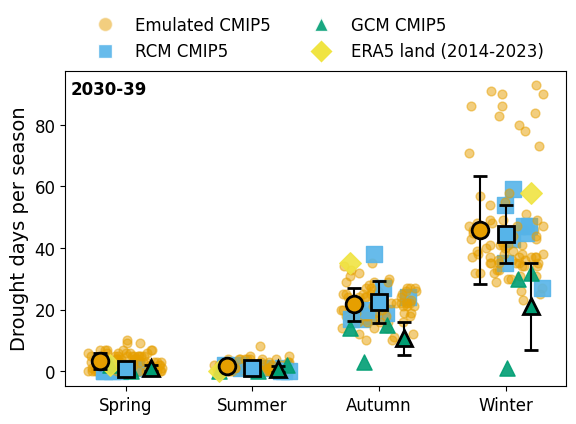

In [4]:
# Collect file lists
seed = 42
rng = np.random.default_rng(seed)
emul_files = sorted(glob.glob("../plotting_data/single_location/emulated/*.npy"))
orig_files = sorted(glob.glob("../plotting_data/single_location/RCM/*.npy"))
gcm_files = sorted(glob.glob("../plotting_data/single_location/GCM/*.npy"))

n_models = len(emul_files)
colors = cm.get_cmap("tab10", n_models)  # For individual colors

emul_color = "#E69F00"
orig_color = "#56B4E9"
gcm_color = "#009E73"

fig, ax = plt.subplots(figsize=(6, 4.5))

# Containers to accumulate data for mean/std computation
all_emul = []
all_orig = []
all_gcm = []

new_order = [1, 2, 0, 3]

# --- Emulated and Original ---
for emul_file, orig_file in zip(emul_files, orig_files):
    # --- Emulated ---
    season_counts_np = np.load(emul_file, allow_pickle=True)
    if isinstance(season_counts_np, dict):
        season_counts_np = list(season_counts_np.values())[0]

    ensembles, n_seasons = season_counts_np.shape

    # Reorder columns
    season_counts_np = season_counts_np[:, new_order]
    all_emul.append(season_counts_np)

    for e in range(ensembles):
        x = np.arange(n_seasons) + np.random.uniform(-0.3, 0.3, size=n_seasons)
        y = season_counts_np[e, :]
        plt.scatter(x, y, color=emul_color, alpha=0.5, s=40)

    # --- Original ---
    season_counts_np = np.load(orig_file, allow_pickle=True)
    if isinstance(season_counts_np, dict):
        season_counts_np = list(season_counts_np.values())[0]

    # Reorder
    season_counts_np = season_counts_np[new_order]
    all_orig.append(season_counts_np)

    x = np.arange(n_seasons) + np.random.uniform(-0.3, 0.3, size=n_seasons)
    y = season_counts_np
    plt.scatter(x, y, color=orig_color, marker="s", s=120, alpha=0.9)

# --- GCM ---
for gcm_file in gcm_files:
    season_counts_np = np.load(gcm_file, allow_pickle=True)
    if isinstance(season_counts_np, dict):
        season_counts_np = list(season_counts_np.values())[0]

    # Reorder
    season_counts_np = season_counts_np[new_order]
    all_gcm.append(season_counts_np)

    n_seasons = len(season_counts_np)
    x = np.arange(n_seasons) + np.random.uniform(-0.3, 0.3, size=n_seasons)
    y = season_counts_np
    plt.scatter(x, y, color=gcm_color, marker="^", s=120, alpha=0.9)

era_land = np.array([35, 2, 0, 58])
season_counts_np = era_land[new_order]
plt.scatter(x, season_counts_np, color="#F0E442", marker="D", s=120, alpha=0.9)
# --- Compute means and std ---
emul_stack = np.vstack(all_emul)
orig_stack = np.vstack(all_orig)
gcm_stack = np.vstack(all_gcm)

emul_mean = np.mean(emul_stack, axis=0)
emul_std = np.std(emul_stack, axis=0)

orig_mean = np.mean(orig_stack, axis=0)
orig_std = np.std(orig_stack, axis=0)

gcm_mean = np.mean(gcm_stack, axis=0)
gcm_std = np.std(gcm_stack, axis=0)

x_vals = np.arange(n_seasons)

x_vals = np.arange(n_seasons)
offset = 0.2  # horizontal offset

# Emulated mean ± std (shift left)
plt.errorbar(
    x_vals - offset,
    emul_mean,
    yerr=emul_std,
    fmt="o",
    color=emul_color,
    markeredgecolor="black",
    ecolor="black",
    markeredgewidth=2,
    markersize=12,
    label="Emulated mean ± std",
    capsize=5,
)

# Original mean ± std (center)
plt.errorbar(
    x_vals,
    orig_mean,
    yerr=orig_std,
    fmt="s",
    color=orig_color,
    markeredgecolor="black",
    ecolor="black",
    markeredgewidth=2,
    markersize=12,
    label="Original mean ± std",
    capsize=5,
)

# GCM mean ± std (shift right)
plt.errorbar(
    x_vals + offset,
    gcm_mean,
    yerr=gcm_std,
    fmt="^",
    color=gcm_color,
    markeredgecolor="black",
    ecolor="black",
    markeredgewidth=2,
    markersize=12,
    label="GCM mean ± std",
    capsize=5,
)


# Axis labels
season_names = ["Spring", "Summer", "Autumn", "Winter"]
plt.xticks(np.arange(4), season_names)
plt.ylabel("Drought days per season")

# Custom legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=emul_color,
        markersize=10,
        alpha=0.5,
        label="Emulated CMIP5",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor=orig_color,
        markersize=10,
        alpha=0.9,
        label="RCM CMIP5",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        color="w",
        markerfacecolor=gcm_color,
        markersize=10,
        alpha=0.9,
        label="GCM CMIP5",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        color="w",
        markerfacecolor="#F0E442",
        markersize=12,
        label="ERA5 land (2014-2023)",
    ),
]

plt.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.22),
    ncol=2,
    frameon=False,
)
ax.text(
    0.01,
    0.97,
    "2030-39",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
)
plt.tight_layout()
plt.subplots_adjust(top=0.81)
plt.savefig("../plots/0079_eraland_included.pdf")
plt.show()